In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset-guidewire_sample.csv to dataset-guidewire_sample.csv


In [ ]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

In [ ]:
df = pd.read_csv("dataset-guidewire_sample.csv")

df.head()

,clause,risk
0,Claims will be reviewed and paid when they com...,Low
1,Coverage may apply in certain situations subje...,High
2,Claims may be approved or declined based on th...,High
3,Claims may be settled according to the insurer...,High
4,The insurer may compensate the insured dependi...,High


In [ ]:
df["risk"].value_counts()

,count
risk,
Low,2500
High,2500


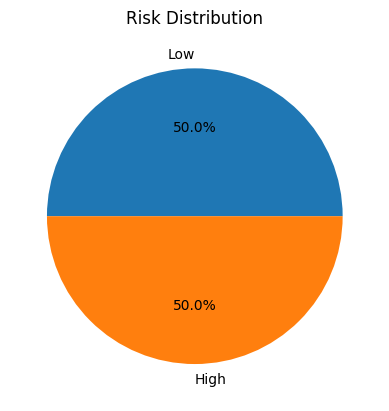

In [ ]:
import matplotlib.pyplot as plt

counts = df["risk"].value_counts()

plt.figure()
counts.plot.pie(autopct='%1.1f%%')
plt.ylabel("")
plt.title("Risk Distribution")
plt.show()

In [ ]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    sublinear_tf=True
)
X = vectorizer.fit_transform(df["clause"])

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(df["risk"])

print("Label Mapping:")
for i,label in enumerate(encoder.classes_):
    print(i,"→",label)

Label Mapping:
0 → High
1 → Low


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
lr_model = LogisticRegression(
    max_iter=4000,
    solver="lbfgs"
)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=4000)

In [ ]:
train_scores = lr_model.predict_proba(X_train).max(axis=1).reshape(-1,1)

test_scores = lr_model.predict_proba(X_test).max(axis=1).reshape(-1,1)

In [ ]:
from scipy.sparse import hstack

train_prob = lr_model.predict_proba(X_train)
test_prob = lr_model.predict_proba(X_test)

X_train_combined = hstack([X_train, train_prob])
X_test_combined = hstack([X_test, test_prob])

In [ ]:
svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)
svm_model.fit(X_train_combined, y_train)

SVC(C=10)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "eugenesiow/bart-paraphrase"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [ ]:
from scipy.sparse import hstack

def rewrite_clause(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True
    )

    outputs = model.generate(
        **inputs,
        max_new_tokens=80,
        num_beams=6,
        no_repeat_ngram_size=3,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)


def analyze_clause(text):

    vec = vectorizer.transform([text])

    prob = lr_model.predict_proba(vec)[0]

    combined = hstack([vec, prob.reshape(1,-1)])

    risk = svm_model.predict(combined)

    risk_label = encoder.inverse_transform(risk)[0]

    print("Clause:", text)

    print("\nLogistic Regression Probabilities:")
    print("High Risk Probability:", round(prob[0],3))
    print("Low Risk Probability:", round(prob[1],3))

    print("\nSVM Risk Classification:")
    print("Risk Category:", risk_label)

    if risk_label == "High":

        improved = rewrite_clause(text)


        print(improved)

In [ ]:
analyze_clause(
"The insurer may provide compensation to the insured in certain situations depending on internal evaluation and other relevant circumstances."
)

Clause: The insurer may provide compensation to the insured in certain situations depending on internal evaluation and other relevant circumstances.

Logistic Regression Probabilities:
High Risk Probability: 0.976
Low Risk Probability: 0.024

SVM Risk Classification:
Risk Category: High
Depending on internal evaluation and other relevant circumstances, the insurance company may provide compensation to the insured in certain situations.
